学习率衰减是一个非常有效的炼丹技巧之一，在神经网络的训练过程中，当accuracy出现震荡或loss不再下降时，进行适当的学习率衰减是一个行之有效的手段，很多时候能明显提高accuracy。


# 基础几类
等间隔调整(Step)，多间隔调整(MultiStep)，指数衰减(Exponential)，余弦退火(CosineAnnealing)

In [25]:
import matplotlib.pyplot as plt

def plot_lr_schedule(scheduler, epochs):
    """
    绘制学习率变化曲线
    
    Args:
        scheduler: torch.optim.lr_scheduler 对象
        epochs: 模拟的训练 epoch 数
    """
    lr_values = []
    for epoch in range(epochs):
        scheduler.step()
        lr_values.append(scheduler.get_last_lr()[0])

    plt.figure()
    plt.plot(range(epochs), lr_values)
    plt.xlabel('Epoch')
    plt.ylabel('Learning Rate')
    plt.title(f'{scheduler.__class__.__name__} Schedule')
    plt.grid(True)
    plt.show()


e:\miniconda3\envs\llm\Lib\site-packages\torch\optim\lr_scheduler.py:143: UserWarning:

Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate



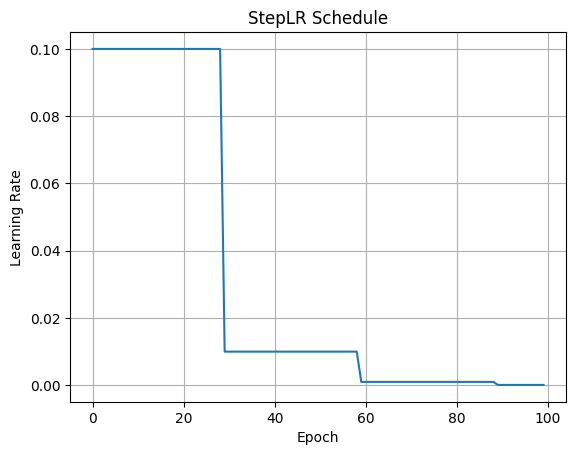

In [26]:
import torch
import torch.optim as optim
from torch.optim import lr_scheduler
from torchvision.models import AlexNet

model = AlexNet(num_classes=2)
optimizer = optim.SGD(params=model.parameters(), lr=0.1)

scheduler = lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.1)

plot_lr_schedule(scheduler, epochs=100)


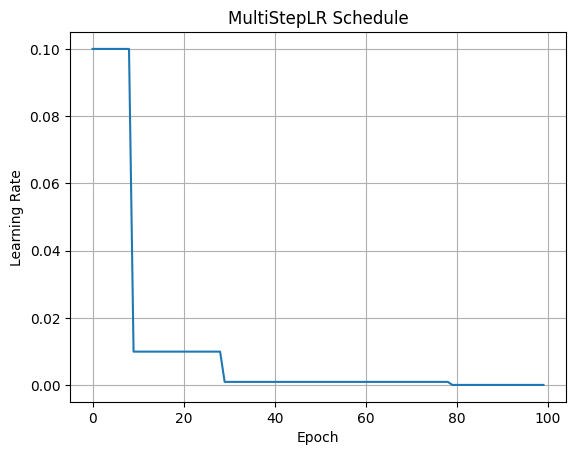

In [27]:
# 多间隔调整学习率，每训练至milestones中的epoch，lr*gamma
optimizer = optim.SGD(params=model.parameters(), lr=0.1)
scheduler = lr_scheduler.MultiStepLR(optimizer, milestones=[10, 30, 80], gamma=0.1)
plot_lr_schedule(scheduler, epochs=100)


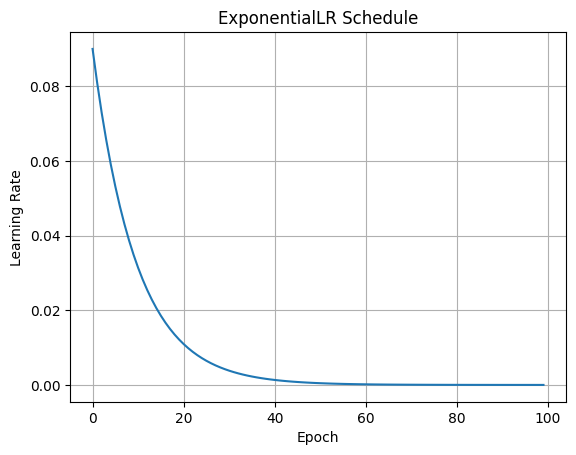

In [28]:
# 指数学习率衰减，lr*gamma**epoch
optimizer = optim.SGD(params=model.parameters(), lr=0.1)
scheduler = lr_scheduler.ExponentialLR(optimizer, gamma=0.9)
plot_lr_schedule(scheduler, epochs=100)

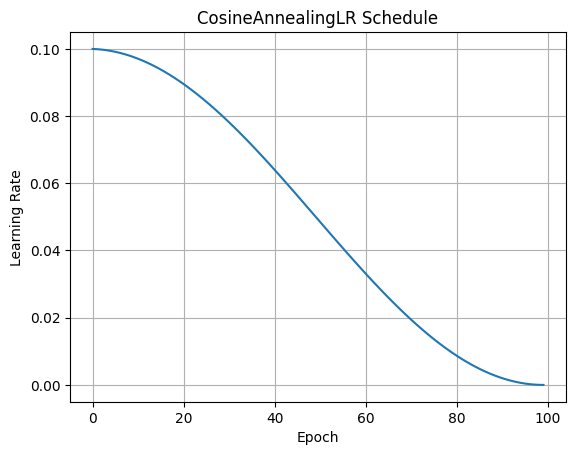

In [29]:
# 余弦退火学习率衰减，T_max表示半个周期，lr的初始值作为余弦函数0处的极大值逐渐开始下降，
# 在epoch=T_max时lr降至最小值，即pi/2处，然后进入后半个周期，lr增大
optimizer = optim.SGD(params=model.parameters(), lr=0.1)
scheduler = lr_scheduler.CosineAnnealingLR(optimizer, T_max=100, eta_min=0)
plot_lr_schedule(scheduler, epochs=100)

# transformer中warm up

用于提升模型学习稳定性。

做法是学习率先warm up线性增长，再按照 1/sqrt(step) 规律缓慢下降。

学习率的warm up为何有效呢？

一种解释性观点是认为这能够让模型初始学习时参数平稳变化并避免对开始的几个batch数据过拟合陷入局部最优。

由于刚学习时，loss比较大，梯度会很大，如果学习率也很大，两者相乘会更大，那么模型参数会随着不同batch数据的差异剧烈抖动，无法有效地学习，也容易对开始的几个batch数据过拟合，后期很难拉回来。

等到模型学习了一些时候，loss变小了，梯度也会小，学习率调大，两者相乘也不会很大，模型依然可以平稳有效地学习。

后期为何又要让调低学习率呢？

这是因为后期模型loss已经很小了，在最优参数附近了，如果学习率过大，容易在最优参数附近震荡，无法逼近最优参数。

参考：https://www.zhihu.com/question/338066667


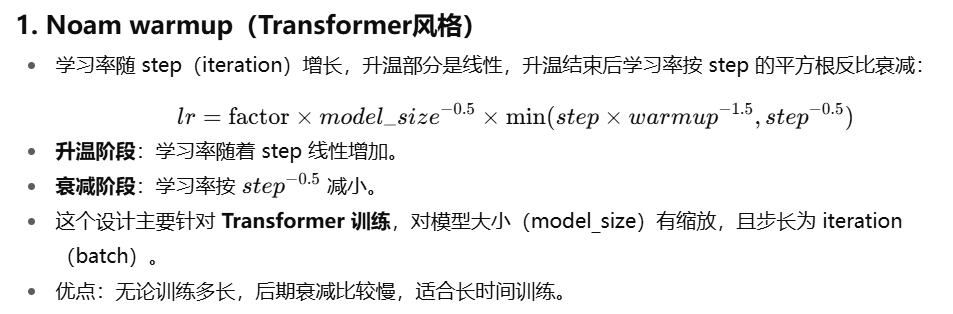

In [30]:
class NoamOpt(torch.optim.AdamW):
    def __init__(self, params, factor=1.0, warmup=4000, 
                 lr=0, betas=(0.9, 0.98), eps=1e-9,
                 weight_decay=0, amsgrad=False):
        super(NoamOpt, self).__init__(params, lr=lr, betas=betas, eps=eps,
                                      weight_decay=weight_decay, amsgrad=amsgrad)
        self._step = 0
        self.warmup = warmup
        self.factor = factor
        self.model_size = 1  # AlexNet 没有 d_model，设为常数即可
        
    def step(self, closure=None):
        self._step += 1
        rate = self.rate()
        for p in self.param_groups:
            p['lr'] = rate
        super(NoamOpt, self).step(closure=closure)
        
    def rate(self, step=None):
        if step is None:
            step = self._step
        return self.factor * (
            self.model_size ** (-0.5) *
            min(step * self.warmup ** (-1.5), step ** (-0.5))
        )

# AlexNet 例子
net = AlexNet(num_classes=2)
optimizer = NoamOpt(net.parameters(), factor=1.0, warmup=400)


In [31]:
import plotly.express as px 
import numpy as np
import pandas as pd

# 不再传 model_size 参数
opts = [
    NoamOpt(net.parameters(), factor=1, warmup=4000),
    NoamOpt(net.parameters(), factor=1, warmup=8000),
    NoamOpt(net.parameters(), factor=1, warmup=2000)
]

# 按 step 计算 lr
steps = np.arange(1, 20000)
rates = [[opt.rate(i) for opt in opts] for i in steps]

# 转成 DataFrame
dfrates = pd.DataFrame(rates, columns=["warmup=4000", "warmup=8000", "warmup=2000"])
dfrates["steps"] = steps 

# 绘制曲线
fig = px.line(dfrates, x="steps", y=["warmup=4000", "warmup=8000", "warmup=2000"])
fig.layout.yaxis.title = "Learning Rate"
fig


# warmup + cosine anneal 余弦退火
跟上一个差不多 不依赖单个公式 后面改余弦而已
https://zhuanlan.zhihu.com/p/674164759

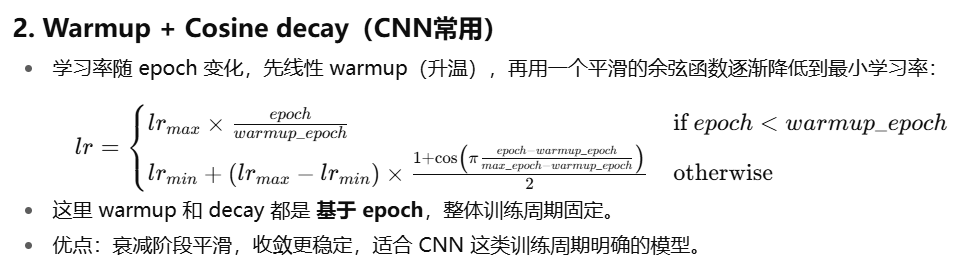

In [32]:
import math
import numpy as np
import pandas as pd
import plotly.express as px
import torch
from math import cos, pi

# warmup + cosine 学习率调度
def warmup_cosine(current_epoch, max_epoch, lr_min=0, lr_max=0.1, warmup_epoch=10):
    if current_epoch < warmup_epoch:
        return lr_max * current_epoch / warmup_epoch
    else:
        return lr_min + (lr_max - lr_min) * \
               (1 + cos(pi * (current_epoch - warmup_epoch) / (max_epoch - warmup_epoch))) / 2

# 参数
lr_max = 0.01
lr_min = 0.0001
max_epoch = 1000
warmup_epoch = 250

# 计算每个 epoch 的学习率
epochs = np.arange(0, max_epoch + 1)
lrs = [warmup_cosine(e, max_epoch, lr_min, lr_max, warmup_epoch) for e in epochs]

# 转为 DataFrame 方便绘图
df = pd.DataFrame({
    "epoch": epochs,
    "learning_rate": lrs
})

# 绘制曲线
fig = px.line(df, x="epoch", y="learning_rate", title="Warmup + Cosine Learning Rate Schedule")
fig.layout.yaxis.title = "Learning Rate"
fig.layout.xaxis.title = "Epoch"
fig
